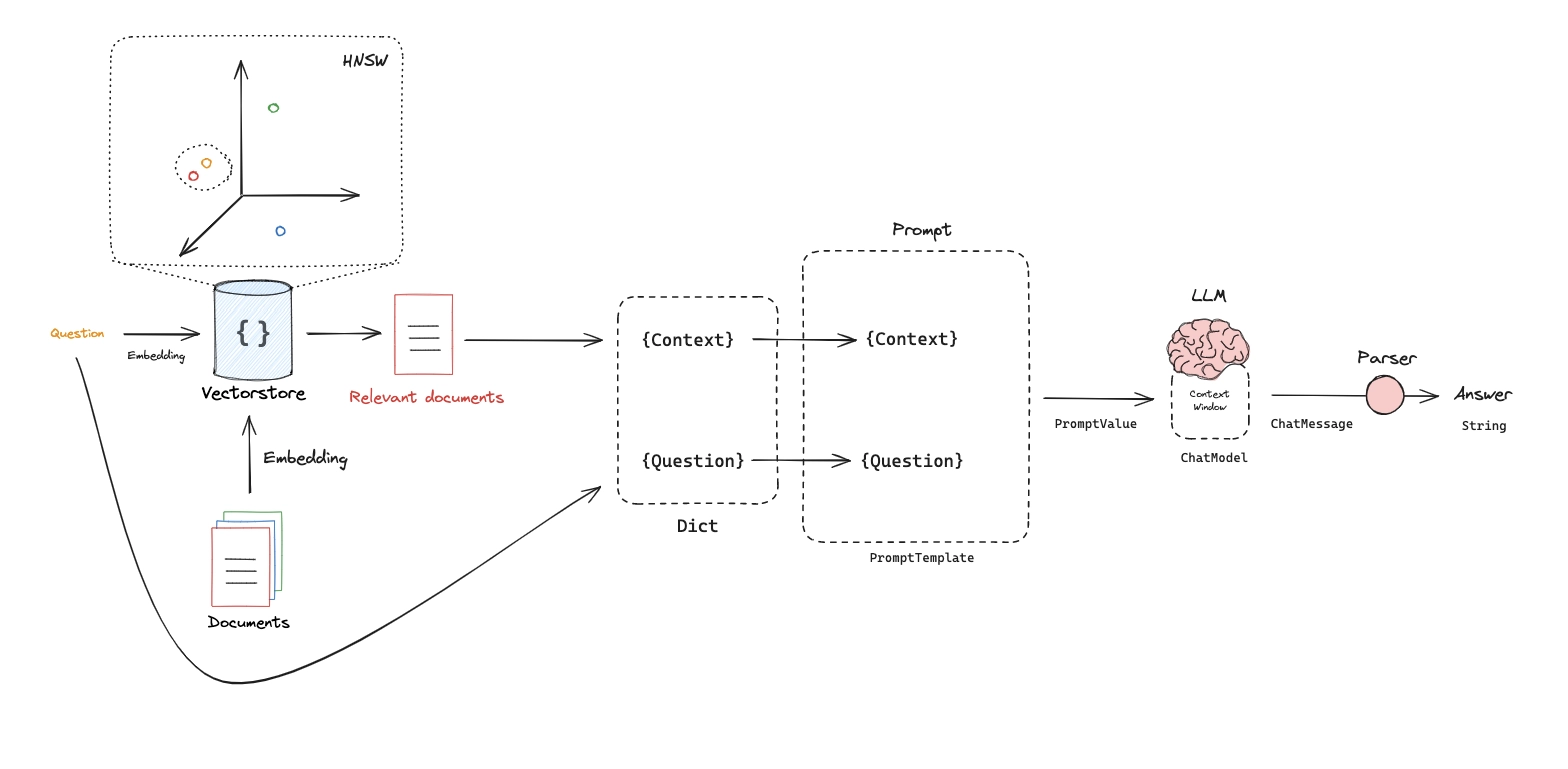

# Как работает RAG

## **Индексация**

1. **Загрузка**: загрузчики документов (PDF, текст, etc)
см тут: https://docs.langchain.com/oss/python/integrations/document_loaders#pdfs

Вот конспект по document loaders, только самое нужное.

**PDF**
PyPDF — базовый, простой текст. PyMuPDF4LLM — конвертирует в markdown, сохраняет заголовки. PDFPlumber — хорош для таблиц. MathPix — формулы как картинки (платный). Amazon Textract — OCR через AWS (платный).

**Веб**
WebBaseLoader — простой HTML через BeautifulSoup, статичные сайты. RecursiveURL — рекурсивно обходит весь сайт по ссылкам от одного URL. Sitemap — грузит все страницы через sitemap.xml. FireCrawl / Spider — платные API, сразу отдают чистый markdown, не надо чистить HTML. Apify — готовые парсеры под конкретные сложные сайты (LinkedIn, Instagram и тд), платно.

**Соцсети и мессенджеры**
Twitter, Reddit — прямые загрузчики постов. Telegram, Discord, WhatsApp — экспорт истории чатов.

**Файлы**
CSV, JSON, HTML — из коробки. Microsoft Word, Excel, PowerPoint — есть отдельные лоадеры. Unstructured — универсальный, тянет почти любой формат.

**Продуктивность**
Notion, Slack, GitHub, Google Drive — прямые интеграции через API.

**Специализированные**
RSS Feeds — новостные ленты без написания парсера. YouTube — транскрипты видео. Arxiv — научные статьи по запросу или ID. PubMed — медицина и наука. Wikipedia — напрямую. HuggingFace Dataset — датасеты с HF.

2. **Разделение**: разбиваем большие документы на чанки
см тут: https://docs.langchain.com/oss/python/integrations/splitters

3. **Store**: векторное хранилище + embeddings для поиска

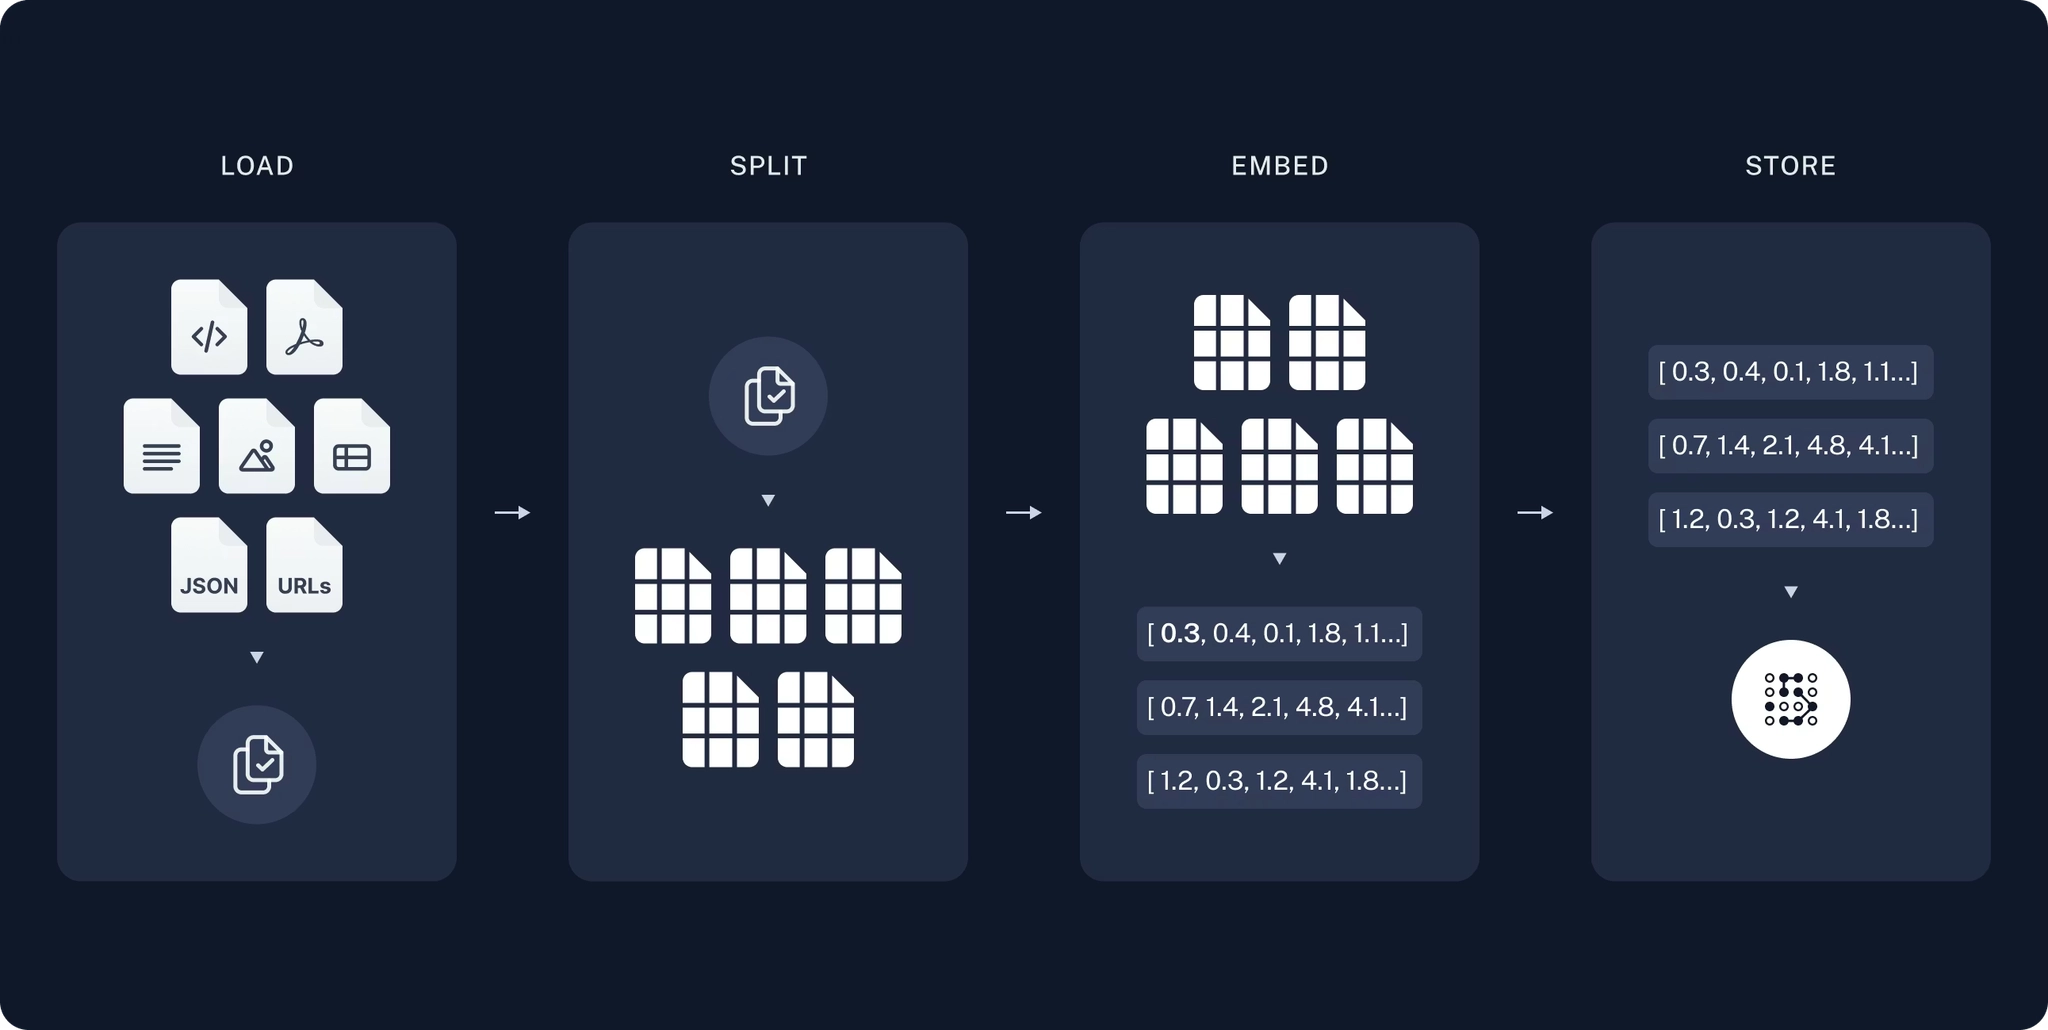


### **Загрузка документов**

TextLoader загружает любые обычные текстовые файлы (.txt, .md, .log и т. д.) и просто читает их содержимое как единый сплошной текст. Он не анализирует структуру документа, не делит его на страницы и не восстанавливает форматирование – результатом всегда будет один Document с текстом, считанным "как есть".

In [ ]:
from langchain_community.document_loaders import TextLoader

loader = TextLoader("blabla", encoding="utf-8")
docs = loader.load()

In [14]:
# загрузка всех !!! PDF из папки, страницы одного файла объединяются в один Document ---

from langchain_community.document_loaders import PyPDFLoader
from langchain_core.documents import Document
from pathlib import Path
import time

start_load = time.time()
print("📚 Загрузка PDF с объединением страниц...\n")

materials_dir = Path("./materials")
pdf_files = sorted(materials_dir.glob("*.pdf"))

docs = []
for pdf_path in pdf_files:
    print(f"  Загружаю: {pdf_path.name}")
    loader = PyPDFLoader(str(pdf_path))
    pages = loader.load()
    # объединяем все страницы одного файла в один Document
    combined_text = "\n\n".join(p.page_content for p in pages)
    combined_doc = Document(
        page_content=combined_text,
        metadata={"source": str(pdf_path)},
    )
    docs.append(combined_doc)
    print(f"    → {len(pages)} страниц → 1 документ ({len(combined_text):,} сим)")

print(f"\n✅ Загружено документов: {len(docs)} (файлов: {len(pdf_files)})")

elapsed_load = time.time() - start_load
print(f"⏱ Время загрузки: {elapsed_load:.2f} секунд\n")

# all unique sources
sources = set(d.metadata.get("source", "") for d in docs)
print(f"📂 Уникальные источники: {len(sources)}")

📚 Загрузка PDF с объединением страниц...

  Загружаю: MATH_EV_PCA.pdf
    → 46 страниц → 1 документ (13,690 сим)
  Загружаю: MATH_limits.pdf
    → 39 страниц → 1 документ (9,405 сим)
  Загружаю: ML3.pdf
    → 31 страниц → 1 документ (9,983 сим)
  Загружаю: Statistics and Chemometrics for Analytical Chemistry 6th.pdf
    → 297 страниц → 1 документ (713,163 сим)

✅ Загружено документов: 4 (файлов: 4)
⏱ Время загрузки: 20.36 секунд

📂 Уникальные источники: 4


### **Разделение документов**

Разбиваем большой документ на чанки. Есть несколько способов:
- По символам (RecursiveCharacterTextSplitter)
- По структуре/заголовкам (MarkdownHeaderTextSplitter)
- По предложениям (NLTKTextSplitter)


In [15]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from pathlib import Path
import time
import statistics

# docs уже загружены из папки выше

# Путь к книге
book_path = Path("./materials/Statistics and Chemometrics for Analytical Chemistry 6th.pdf")
book_source = str(book_path)

# --- КНИГА: по символам (сканированный PDF, структуры нет) ---

# для замера времени обработки
start_time = time.time()
print("📚 Обработка книги по символам...")

book_docs = [d for d in docs if book_path.name in d.metadata.get("source", "")]
print(f"  Страниц книги: {len(book_docs)}")

book_splitter = RecursiveCharacterTextSplitter(
    separators=["\n\n", "\n", ". ", " ", ""],
    chunk_size=3500,      # больше чем остальное, чтобы не разрывать формулы
    chunk_overlap=300,
)

book_chunks = book_splitter.split_documents(book_docs)
print(f"  ✓ Разделено на: {len(book_chunks)} чанков")
print(f"  Размер: {min(len(c.page_content) for c in book_chunks)}-{max(len(c.page_content) for c in book_chunks)} сим\n")

# прошло времени
elapsed_time = time.time() - start_time
print(f"⏱ Время обработки книги: {elapsed_time:.2f} секунд\n")

# --- ОСТАЛЬНОЕ: по символам ---
# для замера времени обработки
start_time_2 = time.time()
print("📄 Обработка остальных документов по символам...")

other_docs = [d for d in docs if book_path.name not in d.metadata.get("source", "")]
print(f"  Других документов: {len(other_docs)} страниц")

other_splitter = RecursiveCharacterTextSplitter(
    separators=["\n\n", "\n", ". ", " ", ""],
    chunk_size=2000,
    chunk_overlap=200,
)

other_chunks = other_splitter.split_documents(other_docs)
print(f"  ✓ Разделено на: {len(other_chunks)} чанков")
print(f"  Размер: {min(len(c.page_content) for c in other_chunks)}-{max(len(c.page_content) for c in other_chunks)} сим\n")

# прошло времени
elapsed_time_2 = time.time() - start_time_2
print(f"⏱ Время обработки остальных документов: {elapsed_time_2:.2f} секунд\n")

# --- ВСЕ ВМЕСТЕ ---
all_chunks = book_chunks + other_chunks

#summary time in minutes
total_time = (elapsed_time + elapsed_time_2) / 60
print(f"⏱ ИТОГО время обработки: {total_time:.2f} минут\n")


print(f"✅ ИТОГО: {len(all_chunks)} чанков")
print(f"   Книга: {len(book_chunks)}")
print(f"   Остальное: {len(other_chunks)}")

# Примеры
print("\n📋 Примеры:")
print(f"\nИз КНИГИ (чанк 0):")
print(f"  Source: {all_chunks[0].metadata.get('source')}")
print(f"  Текст: {all_chunks[0].page_content[:150]}...\n")

print(f"Из ОСТАЛЬНОГО (чанк {len(book_chunks)}):")
print(f"  Source: {all_chunks[len(book_chunks)].metadata.get('source')}")
print(f"  Текст: {all_chunks[len(book_chunks)].page_content[:150]}...")

# --- КОНТРОЛЬ ПОТЕРЬ ПРИ ПАРСИНГЕ ---
print("\n🔍 КОНТРОЛЬ КАЧЕСТВА:")

# Суммируем текст во всех документах
original_total = sum(len(d.page_content) for d in docs)
print(f"  Оригинальный текст: {original_total:,} символов")

# Суммируем текст во всех чанках
chunks_total = sum(len(c.page_content) for c in all_chunks)
print(f"  После чанкования: {chunks_total:,} символов")

# Потери из-за overlap (нормально, это контролируемо)
loss_percent = (1 - chunks_total / original_total) * 100
print(f"  Потери: {loss_percent:.1f}% (overlap + граничные символы)\n")

# Проверяем чанки по источникам
print("  По источникам:")
for source in sources:
    source_docs = [d for d in docs if d.metadata.get("source") == source]
    source_chunks = [c for c in all_chunks if c.metadata.get("source") == source]
    source_chars = sum(len(d.page_content) for d in source_docs)
    print(f"    {Path(source).name}: {len(source_docs)} стр. → {len(source_chunks)} чанков ({source_chars:,} сим)")

# --- СТАТИСТИКА ПО РАЗМЕРАМ ЧАНКОВ ---
print("\n📊 СТАТИСТИКА ЧАНКОВ:")

book_sizes = [len(c.page_content) for c in book_chunks]
other_sizes = [len(c.page_content) for c in other_chunks]
all_sizes = book_sizes + other_sizes

print(f"  КНИГА (целевой размер 3500):")
print(f"    Среднее: {statistics.mean(book_sizes):.0f} сим")
print(f"    Медиана: {statistics.median(book_sizes):.0f} сим")
print(f"    Std Dev: {statistics.stdev(book_sizes):.0f} сим\n")

print(f"  ОСТАЛЬНОЕ (целевой размер 2000):")
print(f"    Среднее: {statistics.mean(other_sizes):.0f} сим")
print(f"    Медиана: {statistics.median(other_sizes):.0f} сим")
print(f"    Std Dev: {statistics.stdev(other_sizes):.0f} сим\n")

print(f"  ВСЕ ВМЕСТЕ:")
print(f"    Среднее: {statistics.mean(all_sizes):.0f} сим")
print(f"    Медиана: {statistics.median(all_sizes):.0f} сим")
print(f"    Std Dev: {statistics.stdev(all_sizes):.0f} сим")

📚 Обработка книги по символам...
  Страниц книги: 1
  ✓ Разделено на: 295 чанков
  Размер: 239-3496 сим

⏱ Время обработки книги: 0.03 секунд

📄 Обработка остальных документов по символам...
  Других документов: 3 страниц
  ✓ Разделено на: 20 чанков
  Размер: 466-1999 сим

⏱ Время обработки остальных документов: 0.01 секунд

⏱ ИТОГО время обработки: 0.00 минут

✅ ИТОГО: 315 чанков
   Книга: 295
   Остальное: 20

📋 Примеры:

Из КНИГИ (чанк 0):
  Source: materials/Statistics and Chemometrics for Analytical Chemistry 6th.pdf
  Текст: Statistics and 
Chemometrics
for Analytical
Chemistry
Sixth edition
James N Miller
Jane C Miller
Statistics and 
Chemometrics 
for Analytical Chemistr...

Из ОСТАЛЬНОГО (чанк 295):
  Source: materials/MATH_EV_PCA.pdf
  Текст: 3. Матричные разложения
• выпускница механико-математического факультета МГУ
• преподаватель и автор курсов для бакалавриата Центрального Университета...

🔍 КОНТРОЛЬ КАЧЕСТВА:
  Оригинальный текст: 746,241 символов
  После чанкования: 75

### Создаём embeddings

После разбиения текста на чанки нам нужно преобразовать каждый фрагмент в числовое представление – **эмбеддинг**.

Эмбеддинги – это векторы из десятков, сотен или тысяч чисел, и каждый такой вектор – это точка в многомерном пространстве. В этом пространстве смысловые связи отражаются геометрически: похожие тексты оказываются "близко" друг к другу, а непохожие – далеко. Векторное хранилище (например, Chroma, Qdrant или Pinecone) сохраняет эти точки и позволяет быстро находить ближайшие, измеряя расстояние между ними через cosine similarity, dot product или другую метрику. Именно это и делает возможным семантический поиск: модель не ищет совпадение слов – она ищет **смысловую близость в пространстве эмбеддингов**.
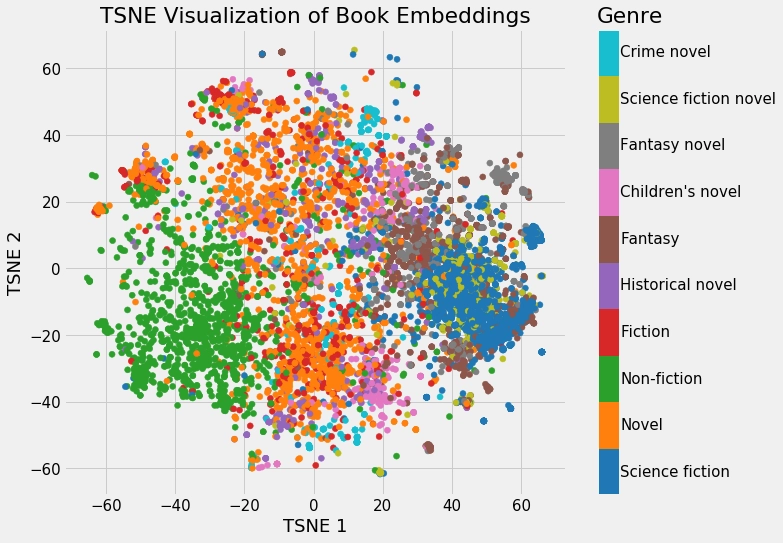

Модель для создания эмбеддингов – это специальная нейросеть, которая преобразует текст в такие векторные представления и позволяет выполнять семантический поиск по базе документов.
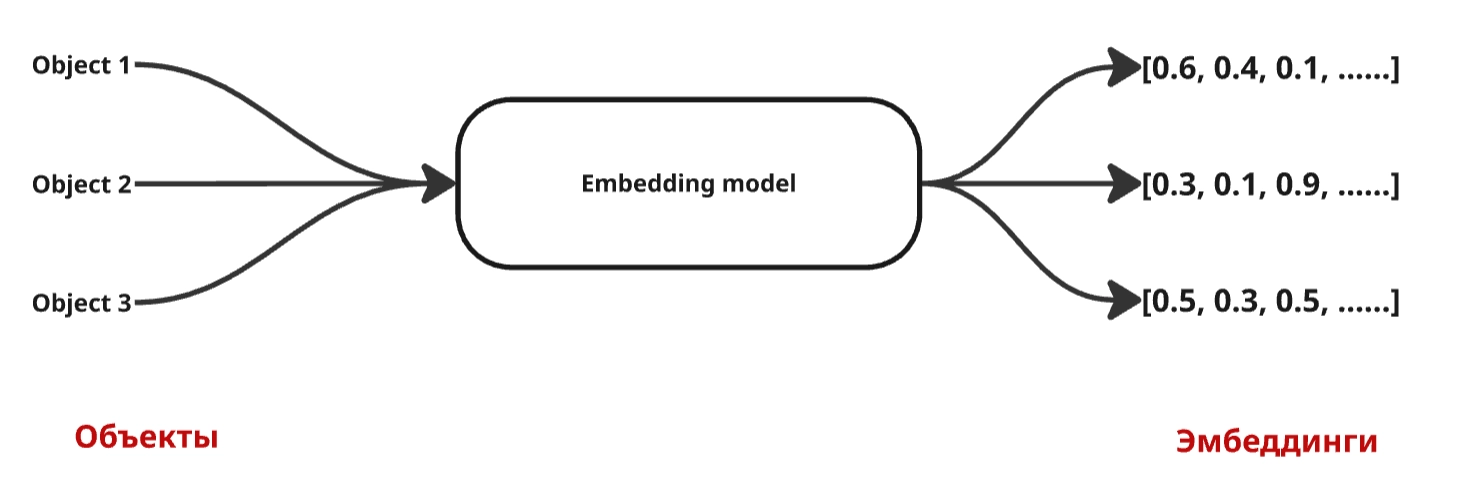

От выбора embedding-модели зависит качество поиска: чем лучше она понимает язык и контекст, тем точнее система сможет находить нужные фрагменты. Выбор модели определяется языком данных, доступными ресурсами (нужна ли локальная модель или облачная) и требуемым балансом между скоростью, стоимостью и качеством.

Здесь https://docs.langchain.com/oss/python/integrations/embeddings главное не список провайдеров (их 70+, большинство не нужны), а концепции.

**Суть**

Embedding модель — отдельная от LLM. LLM отвечает на вопросы, embedding модель только переводит текст в векторы. Это разные задачи, разные модели.

Два метода у любой embedding модели: `embed_documents(texts)` — векторизует список чанков (при индексации), `embed_query(text)` — векторизует один вопрос (при поиске).

**Метрики схожести** — cosine similarity (угол между векторами), Euclidean distance (расстояние), dot product. На практике везде используют cosine similarity.

**Провайдеры которые реально нужны**

`OllamaEmbeddings` — локально, бесплатно, твой текущий вариант (snowflake-arctic). `OpenAIEmbeddings` — платно, но качественно, `text-embedding-3-small` дёшево. `HuggingFaceEmbeddings` — запускаешь модель с HF локально через `sentence-transformers`. `NomicEmbeddings` — хорошая бесплатная модель, поддерживает мультиязычность. `FakeEmbeddings` — для тестов, не считает реальные векторы.

**Кэширование**

`CacheBackedEmbeddings` — обёртка которая сохраняет уже посчитанные векторы на диск. Если тот же текст встретится снова — не пересчитывает, берёт из кэша. 

Для нашего примера возьмём локальную какую-нибудь эмбединг модель с [Hugging Face](https://huggingface.co/models) и запустим её локально через Ollama. Пример запроса:

[https://huggingface.co/models?**apps=ollama&language=ru&sort=trending&search=embed**](https://huggingface.co/models?apps=ollama&language=ru&sort=trending&search=embed)


In [16]:
# --- ТЕСТ: запрос к API для получения эмбеддингов ---
import requests

r = requests.post("http://localhost:11434/api/embeddings", json={
    "model": "hf.co/Casual-Autopsy/snowflake-arctic-embed-l-v2.0-gguf:Q4_K_M",
    "prompt": "wateremelons are not tasty",
})
print(r.json()["embedding"][:10], "...")

[0.5312023758888245, 0.6521092653274536, 0.5985397696495056, -1.5771807432174683, 0.0051862820982933044, -0.3054230511188507, -0.22842010855674744, 0.3521425426006317, -0.28601962327957153, -0.03768999129533768] ...


In [17]:
# --- ТЕСТ: использование класса OllamaEmbeddings ---
from langchain_ollama import OllamaEmbeddings

EMBEDDING_MODEL = 'hf.co/Casual-Autopsy/snowflake-arctic-embed-l-v2.0-gguf:Q4_K_M'
OLLAMA_BASE_URL = 'http://127.0.0.1:11434'

embeddings = OllamaEmbeddings(
    model=EMBEDDING_MODEL,      # имя модели в ollama
    base_url=OLLAMA_BASE_URL,   # стандартный адрес ollama
)

example_req = embeddings.embed_query("what is the meaning of 67?")
print(len(example_req), example_req[:10], "...")

1024 [0.02804359, -0.025206562, 0.002376094, -0.033253487, -0.028425762, -0.07306495, 0.04791903, 0.0420879, 0.027418898, -0.014155072] ...


In [18]:
# cosine similarity function for embeddings (just testing)

from sklearn.metrics.pairwise import cosine_similarity

# Cosine similarity — мера похожести между двумя векторами (от 0 до 1)
# 1 = идентичные векторы (одинаковые направления)
# 0 = ортогональные (совсем не похожи)

# Пример с вопросами про небо и солнце
print("☀️  Пример: вопросы про небо и солнце")
q1_embedding = embeddings.embed_query("где находится солнце")
q2_embedding = embeddings.embed_query("где находится небо")
q3_embedding = embeddings.embed_query("какой размер видеокарты")

sim_sun_sky = cosine_similarity([q1_embedding], [q2_embedding])[0][0]
sim_sun_gpu = cosine_similarity([q1_embedding], [q3_embedding])[0][0]

print(f"  'Где солнце' vs 'Где небо': {sim_sun_sky:.4f} (похожие темы)")
print(f"  'Где солнце' vs 'Размер видеокарты': {sim_sun_gpu:.4f} (не похожи)\n")


☀️  Пример: вопросы про небо и солнце
  'Где солнце' vs 'Где небо': 0.7128 (похожие темы)
  'Где солнце' vs 'Размер видеокарты': 0.0882 (не похожи)



### **Хранение документов**

Теперь нам нужно проиндексировать все фрагменты текста, чтобы мы могли выполнять поиск по ним во время выполнения программы. Для этого мы будем использовать векторное хранилище. 

**Векторное хранилище** – это специализированная база данных, оптимизированная для хранения эмбеддингов и поиска ближайших векторов. Обычные базы данных умеют искать по точным совпадениям, но совершенно не подходят для задач семантического поиска, где два текста могут быть написаны разными словами, но иметь одинаковый смысл. Векторное хранилище позволяет эффективно работать с многомерными пространствами, в которых каждая точка представляет смысловую сущность, а поиск осуществляется через сравнение расстояний между векторами.

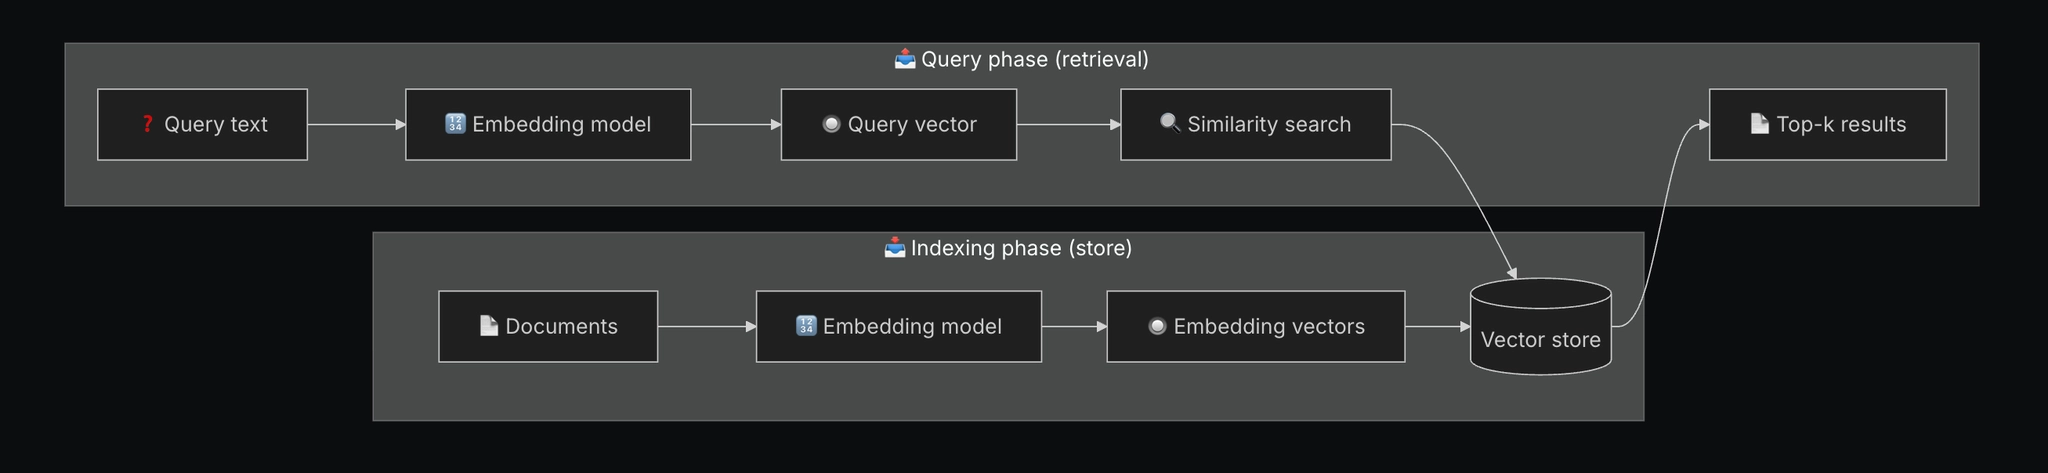



In [ ]:
ТУТ КОД ДОЛЖЕН БЫТЬ ПРО ХРОМУ.

Далее нам необходимо превратить полученное векторное хранилище (Chroma) в **retriever** – объект, который умеет принимать текстовый запрос и возвращать *k наиболее релевантных фрагментов* из базы:

Это упрощённый слой между хранилищем и LLM: он делает семантический поиск, чтобы модель получала только нужные документы, а не всю базу. В данном случае retriever будет каждый раз возвращать **5 лучших совпадений**.

- Дополнительные параметры
    - `search_kwargs` – задаёт тонкие настройки поиска.
    - `k` – сколько документов вернуть;
    - `score_threshold` – минимальное значение сходства для строгого поиска;
    - `fetch_k` и `lambda_mult` используются для MMR, чтобы контролировать баланс между релевантностью и разнообразием;
    - `filter` позволяет выбирать документы по метаданным (например, по автору или источнику).
    
    Всё это делает retriever гибким инструментом для точной настройки RAG.

In [ ]:
retriever = vector_store.as_retriever(search_kwargs={"k": 5})